Check CUDA

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())

Check pixel coord file

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Path to your folder containing images
image_folder = '../1_DatasetCharacteristics/seamounts_seg_cropped'

# Load the CSV file
csv_file = '../1_DatasetCharacteristics/merged_pixel_coordinates.csv'
df = pd.read_csv(csv_file)

# Loop through each row in the CSV file
for _, row in df.iterrows():
    # Get image file name and bounding box coordinates
    image_name = row['image_name']
    x_min, y_min, x_max, y_max = row['x_min'], row['y_min'], row['x_max'], row['y_max']
    
    # Load the image
    image_path = os.path.join(image_folder, image_name)
    image = cv2.imread(image_path)
    
    # Convert image from BGR (OpenCV format) to RGB (matplotlib format)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Draw the bounding box on the image
    cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)  # Red bounding box
    
    # Display the image with the bounding box
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()


Epoch 1/100
13/13 [==============================] - 6s 179ms/step - loss: 1.9831 - mae: 2.2859 - val_loss: 0.0059 - val_mae: 0.0814
Epoch 2/100
13/13 [==============================] - 1s 104ms/step - loss: 0.0228 - mae: 0.1710 - val_loss: 0.0029 - val_mae: 0.0609
Epoch 3/100
13/13 [==============================] - 1s 110ms/step - loss: 0.0209 - mae: 0.1652 - val_loss: 0.0022 - val_mae: 0.0517
Epoch 4/100
13/13 [==============================] - 1s 109ms/step - loss: 0.0192 - mae: 0.1567 - val_loss: 0.0038 - val_mae: 0.0660
Epoch 5/100
13/13 [==============================] - 1s 110ms/step - loss: 0.0167 - mae: 0.1449 - val_loss: 0.0020 - val_mae: 0.0483
Epoch 6/100
13/13 [==============================] - 1s 102ms/step - loss: 0.0165 - mae: 0.1473 - val_loss: 0.0019 - val_mae: 0.0515
Epoch 7/100
13/13 [==============================] - 1s 109ms/step - loss: 0.0179 - mae: 0.1506 - val_loss: 0.0095 - val_mae: 0.1240
Epoch 8/100
13/13 [==============================] - 1s 110ms/step - 

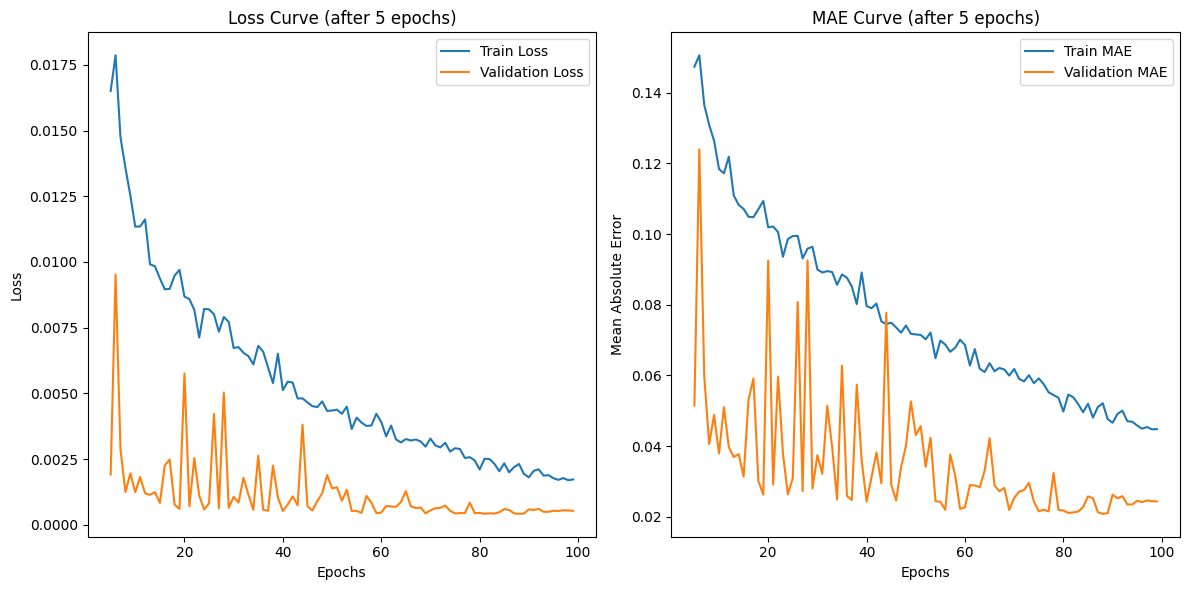

4/4 [==============================] - 0s 23ms/step


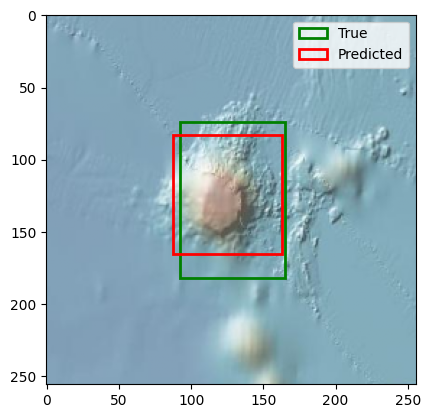

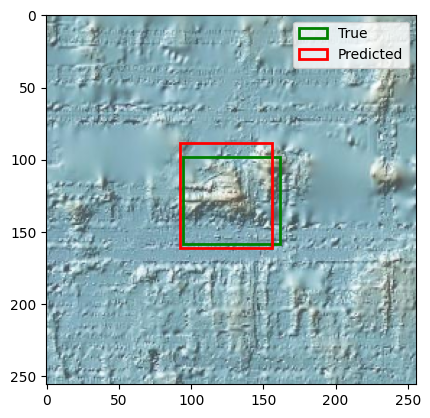

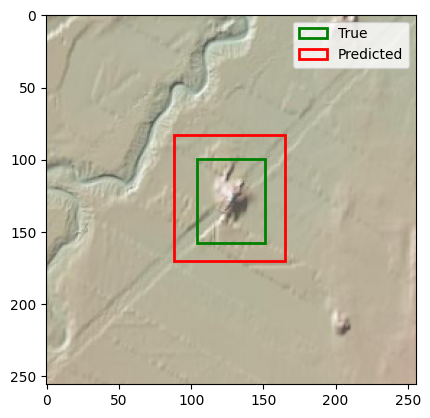

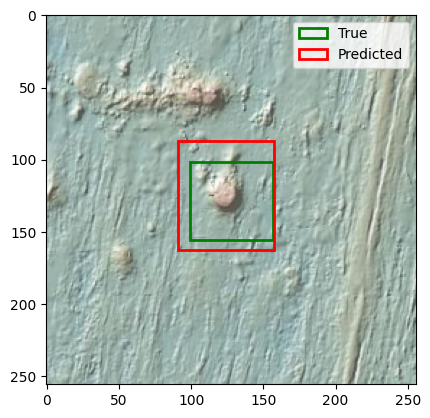

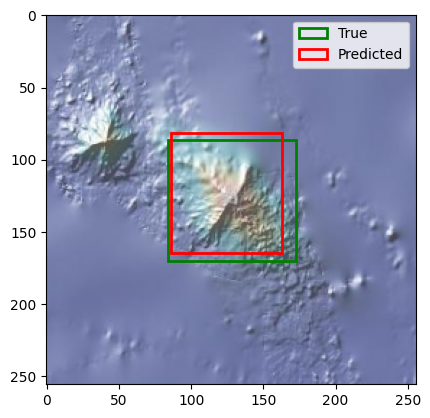

In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths to data
image_dir = "../1_DatasetCharacteristics/seamounts_seg_cropped"
csv_path = "../1_DatasetCharacteristics/merged_pixel_coordinates.csv"

# Constants
IMAGE_SIZE = (256, 256)  # Resize images to 256x256
BATCH_SIZE = 32
EPOCHS = 100

# Load bounding box data
bbox_data = pd.read_csv(csv_path)

# Function to load images
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Load in color (BGR format)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format
    image = image / 255.0  # Normalize pixel values to [0, 1]
    return image

# Function to preprocess bounding boxes
def preprocess_bboxes(row, original_size, resized_size):
    x_min, y_min, x_max, y_max = row[['x_min', 'y_min', 'x_max', 'y_max']]
    orig_height, orig_width = original_size
    resized_height, resized_width = resized_size

    # Scale the bounding box coordinates according to the resizing ratio
    x_min = x_min * (resized_width / orig_width)
    y_min = y_min * (resized_height / orig_height)
    x_max = x_max * (resized_width / orig_width)
    y_max = y_max * (resized_height / orig_height)

    # Normalize coordinates to [0, 1]
    x_min /= resized_width
    y_min /= resized_height
    x_max /= resized_width
    y_max /= resized_height

    return [x_min, y_min, x_max, y_max]

# Prepare dataset
images = []
bboxes = []
for _, row in bbox_data.iterrows():
    img_path = os.path.join(image_dir, row['image_name'])
    if os.path.exists(img_path):
        # Load image without resizing to get original dimensions
        original_image = load_image(img_path)
        original_size = (original_image.shape[0], original_image.shape[1])

        # Preprocess bounding box
        bbox = preprocess_bboxes(row, original_size, IMAGE_SIZE)
        bboxes.append(bbox)

        # Resize the image
        resized_image = cv2.resize(original_image, IMAGE_SIZE)
        images.append(resized_image)

images = np.array(images)
bboxes = np.array(bboxes)

# Split data
X_train, X_val, y_train, y_val = train_test_split(images, bboxes, test_size=0.2, random_state=42)

# Define Huber loss
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= delta
    small_error_loss = 0.5 * tf.square(error)
    large_error_loss = delta * (tf.abs(error) - 0.5 * delta)
    return tf.where(is_small_error, small_error_loss, large_error_loss)

# Define the model architecture
def create_model():
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))  # 3 channels for RGB
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)  # Add dropout to prevent overfitting
    outputs = layers.Dense(4, activation='linear')(x)  # Use 'linear' activation for raw predictions
    model = models.Model(inputs, outputs)
    return model

# Compile model with Huber loss
model = create_model()
model.compile(optimizer='adam', loss=huber_loss, metrics=['mae'])

# Training and validation loss/MAE visualization (Learning curve)
def plot_learning_curve(history, start_epoch=5):
    # Extract loss and MAE for training and validation data
    train_loss = history.history['loss'][start_epoch:]
    val_loss = history.history['val_loss'][start_epoch:]
    train_mae = history.history['mae'][start_epoch:]
    val_mae = history.history['val_mae'][start_epoch:]

    # Plot training and validation loss
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(start_epoch, len(history.history['loss'])), train_loss, label='Train Loss')
    plt.plot(range(start_epoch, len(history.history['val_loss'])), val_loss, label='Validation Loss')
    plt.title('Loss Curve (after 5 epochs)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation MAE
    plt.subplot(1, 2, 2)
    plt.plot(range(start_epoch, len(history.history['mae'])), train_mae, label='Train MAE')
    plt.plot(range(start_epoch, len(history.history['val_mae'])), val_mae, label='Validation MAE')
    plt.title('MAE Curve (after 5 epochs)')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Train the model and get history
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Evaluate model performance
val_loss, val_mae = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}, Validation MAE: {val_mae}")

# Plot learning curve after training, starting from epoch 5
plot_learning_curve(history, start_epoch=5)

# Visualize predictions
def plot_predictions(images, true_bboxes, pred_bboxes):
    for i in range(5):  # Show 5 examples
        img = images[i]
        true_bbox = true_bboxes[i]
        pred_bbox = pred_bboxes[i]

        plt.imshow(img)
        h, w, _ = img.shape

        # Plot true bounding box
        true_rect = [
            true_bbox[0] * w, true_bbox[1] * h,
            (true_bbox[2] - true_bbox[0]) * w, (true_bbox[3] - true_bbox[1]) * h
        ]
        plt.gca().add_patch(plt.Rectangle(
            (true_rect[0], true_rect[1]),
            true_rect[2], true_rect[3],
            edgecolor='green', facecolor='none', lw=2, label='True'
        ))

        # Plot predicted bounding box
        pred_rect = [
            pred_bbox[0] * w, pred_bbox[1] * h,
            (pred_bbox[2] - pred_bbox[0]) * w, (pred_bbox[3] - pred_bbox[1]) * h
        ]
        plt.gca().add_patch(plt.Rectangle(
            (pred_rect[0], pred_rect[1]),
            pred_rect[2], pred_rect[3],
            edgecolor='red', facecolor='none', lw=2, label='Predicted'
        ))

        plt.legend()
        plt.show()

# Make predictions on the validation set
pred_bboxes = model.predict(X_val)

# Plot predictions vs true bounding boxes
plot_predictions(X_val, y_val, pred_bboxes)
